# 🧪 Analíticas de sangre (tabular) — **v3 PESADO** (CPU · máximo nivel · modelo independiente)
## TFM · Módulo Tabular (Laboratorio) · Universidad de Salamanca

---

## 🎯 Qué es esta versión (la más compleja de las 3)
Exprime el techo de la señal tabular (~0.69 AUC) con un **stacking de 2º nivel**: varios modelos base diversos generan
predicciones **out-of-fold**, y un **meta-modelo (LogReg)** aprende a combinarlas por etiqueta. Suele batir al promedio
simple del v2 por unas milésimas.

| Componente | Detalle |
|---|---|
| **Modelos base** | XGBoost, LightGBM (NaN nativo) + LogReg, MLP (percentil imputado) **+ TabPFN (nube, opcional)** |
| **OOF por modelo** | K-fold con imputación/escalado **por fold** (sin fuga) |
| **2º nivel (stacking)** | **meta-LogReg por etiqueta** sobre las probabilidades base; se compara con el promedio simple |
| **Selección** | se queda con stacking o promedio según la **validación** |

## ⏱️ Coste (CPU): el tuning de árboles + K-fold es ~1 h; **TabPFN va por nube** (necesita `TABPFN_TOKEN`). Pon
`USE_TABPFN=False` para una corrida solo-local. Diseñado para **< 24 h**.

## 🛡️ Bases del proyecto (intactas)
Masking de NaN/−1 · **negativos derivados** · sin `cxr_view` · flags de missingness · `scale_pos_weight` · **calibración
isotónica** · **OOF sin fuga** para el stacking multimodal · nombres legibles.


In [19]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try: import torch  # noqa
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","--index-url","https://download.pytorch.org/whl/cpu","-q"],check=True)
for p in ["xgboost","lightgbm","scikit-learn","pandas","numpy","matplotlib","seaborn"]:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q"],check=False)
try: subprocess.run([sys.executable,"-m","pip","install","tabpfn-client","-q"],check=False)
except Exception: pass
print("Dependencias listas.")

Dependencias listas.


In [ ]:
# CELDA 2 · IMPORTS, RUTAS Y CONSTANTES
import os, json, copy, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler          # §2 EDA: la edad NO es gaussiana → escalado robusto
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix
import xgboost as xgb, lightgbm as lgb
warnings.filterwarnings("ignore"); SEED=42; np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(4); DEVICE="cpu"
TABPFN_OK=False
tok=os.environ.get("TABPFN_TOKEN")
if tok:
    try:
        import tabpfn_client; from tabpfn_client import TabPFNClassifier
        tabpfn_client.set_access_token(tok)
        TABPFN_OK=True
    except Exception: TABPFN_OK=False

BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV=BASE/"data_csv"/"clean"; TRAIN_CSV,VAL_CSV,TEST_CSV=CSV/"train_clean.csv",CSV/"val_clean.csv",CSV/"test_clean.csv"
OUTPUT_DIR=Path(r"C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\salidas\03_labs\v3"); OUTPUT_DIR.mkdir(parents=True,exist_ok=True); FIG=OUTPUT_DIR/"figuras"; FIG.mkdir(exist_ok=True)
LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"; PATHOLOGY=[l for l in LABELS if l!=NO_FINDING]; CORE=["Cardiomegaly","Edema","Pleural Effusion"]
K_FOLDS=5; FLAG_THRESH=0.02; USE_TABPFN=TABPFN_OK; TABPFN_MAX=4000

# ── ETIQUETADO FINAL (§3 EDA) ────────────────────────────────────────────────
# POS=(==1) · NEG=(==0)|(NaN→0) · −1 ENMASCARADO (U-Ignore) · «No Finding» NO como negativo.
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=False   # ← antes True; la derivación introduce SESGO DE ESPECTRO
WIDE_NAN_THRESH=0.55                      # >55 % ausente → en modelos DENSOS solo se usa el flag (§4 EDA)
USE_CLUSTER_REPR=False                    # toggle A/B de reducción por clusters fisiológicos (§8 EDA)
# ── CLUSTERS FISIOLÓGICOS (§8 EDA · dendrograma de Ward) ─────────────────────
LAB_CLUSTERS={
 "eritrocitario":["hemoglobin","hematocrit","rbc","mch","mchc","mcv","rdw","nrbc_abs"],
 "renal":["urea_nitrogen","creatinine","sodium","potassium","chloride"],
 "acido_base":["bicarbonate","anion_gap","base_excess","ph","calculated_total_co2","pco2","po2","lactate"],
 "leucocitario":["wbc_count","neutrophils_pct","lymphocytes_pct","monocytes_pct","basophils_pct","eosinophils_pct"],
 "coagulacion":["pt","inr_pt","ptt","fibrinogen","platelet_count"],
 "hepatico":["alt","ast","alkaline_phosphatase","bilirubin_total","albumin"],
 "metabolico":["glucose","phosphate","calcium_total","magnesium"]}
PRIORITY_LABS=["urea_nitrogen","albumin","rdw","creatinine","lymphocytes_pct"]   # §5/§10: nunca se descartan

GENDER={0:0,1:1,"0":0,"1":1,"M":1,"F":0}; RACE={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADM={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}; LOC={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
print("Salidas en", OUTPUT_DIR, "· TabPFN:", USE_TABPFN, "· derive:", DERIVE_NEGATIVES_FROM_EXCLUSIVITY)

In [ ]:
# CELDA 3 · CARGA + OBJETIVOS — definición FINAL del negativo (U-IGNORE del −1)
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
DEMO=["subject_id","hadm_id","cxr_path","ecg_path","age","gender","race","admission_type","admission_location","cxr_view","hours_adm_to_cxr"]
RAW_LABS=[c for c in df_train.columns if c not in LABELS and c not in DEMO and "pctile" not in c]
PCT_LABS=[c for c in df_train.columns if "pctile" in c]

# ══ build_targets ════════════════════════════════════════════════════════════
# QUÉ HACE: convierte los estados 1/0/−1/NaN de cada etiqueta en (labels, mask).
# FINALIDAD: fijar la definición FINAL acordada con el tutor:
#            POS=(==1) · NEG=(==0)|(NaN→0) · −1 ENMASCARADO (U-Ignore de CheXpert).
# ORIGEN EDA: §3 · recuadro naranja "negativo = 0 explícito + NaN→0; el −1 se enmascara;
#            «Sin hallazgo» NO como negativo (evita el sesgo de espectro)".
# CAMBIO vs versión previa: se ELIMINA la derivación de negativos desde «No Finding».
# INTERPRETACIÓN FUTURA (→ recuadro naranja doc): esta definición es COMÚN a CXR, ECG y tabular,
#            requisito para que el stacking multimodal combine probabilidades coherentes.
def build_targets(df, uncertainty_policy="ignore", derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY, verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=(raw==1.0).astype(np.float32)                 # 1 → positivo ; 0 y NaN → 0 (negativo)
    mask  =np.ones((N,N_LABELS),np.float32)              # por defecto TODO entra en pérdida/métrica
    unc=(raw==-1.0)
    if   uncertainty_policy=="ignore": mask[unc]=0.0      # −1 → ENMASCARADO (definición FINAL)
    elif uncertainty_policy=="ones":   labels[unc]=1.0
    ndp=ndn=0
    if derive:  # CONSERVADO por compatibilidad; NO forma parte de la definición FINAL
        nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; ndp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; ndn=int(fn.sum())
    if verbose:
        for j,l in enumerate(LABELS):
            s=mask[:,j]==1; p=int((labels[s,j]==1).sum()); n=int((labels[s,j]==0).sum())
            print(f"   {l:18s} pos={p:5d} neg={n:5d} enmasc={int((mask[:,j]==0).sum()):4d} pos_weight={n/max(p,1):.2f}")
    return labels,mask
y_train,m_train=build_targets(df_train,verbose=True); y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)

In [ ]:
# CELDA 4 · FEATURES (tree: RAW+NaN nativo · dense: PERCENTIL) + ratios + clusters + flags + demografía
# DECISIONES (origen en recuadros naranjas del EDA):
#  · §9 raw≡percentil (r>0,90) → ÁRBOLES=raw, DENSOS=percentil. Nunca ambos.
#  · §4 NaN amplios: en DENSOS, >WIDE_NAN_THRESH entra solo por su flag (prioritarias protegidas).
#  · §6 MNAR → flags de missingness.  · §8 clusters fisiológicos → scores de severidad.
#  · §2 la edad no es gaussiana → RobustScaler (no StandardScaler).
train_miss=df_train[RAW_LABS].isna().mean(); FLAG_LABS=[c for c in RAW_LABS if train_miss[c]>FLAG_THRESH]
_base=lambda c: c.rsplit("_",1)[0]; _item=lambda c: c.rsplit("_",1)[1]
PCT_OF={_item(c):[p for p in PCT_LABS if p.endswith(_item(c))] for c in RAW_LABS}
WIDE_NAN_LABS=[c for c in RAW_LABS if train_miss[c]>WIDE_NAN_THRESH and _base(c) not in PRIORITY_LABS]
DENSE_PCT_KEEP=[p for p in PCT_LABS if not any(p.endswith(_item(c)) for c in WIDE_NAN_LABS)]
print(f"[NaN amplio >{WIDE_NAN_THRESH:.0%}] {len(WIDE_NAN_LABS)} analíticas fuera del denso · percentiles usados {len(DENSE_PCT_KEEP)}/{len(PCT_LABS)}")
def _col(key):
    for c in RAW_LABS:
        if c.startswith(key+"_") or c==key: return c
    return None
C_UREA=_col("urea_nitrogen"); C_CREAT=_col("creatinine"); C_NEUT=_col("neutrophils_pct"); C_LYMPH=_col("lymphocytes_pct"); C_RDW=_col("rdw")

# ══ ratios ═══════════════════════════════════════════════════════════════════
# QUÉ HACE: ratios clínicos desde el valor bruto (BUN/Creatinina, Neutrófilos/Linfocitos, RDW×Edad).
# FINALIDAD: capturar ejes fisiológicos (renal, inflamatorio, cardio) que una analítica sola no da.
# ORIGEN EDA: §5/§10 · recuadro naranja "priorizar Urea, Albúmina, RDW, Creatinina y añadir ratios clínicos".
# INTERPRETACIÓN FUTURA (→ recuadro naranja doc): si los ratios superan a sus componentes en importancia,
#            es evidencia a favor del eje cardio-renal descrito en el EDA.
def ratios(df):
    g=lambda c: df[c].to_numpy(np.float32) if c else np.full(len(df),np.nan,np.float32)
    urea,creat,neut,lymph,rdw=g(C_UREA),g(C_CREAT),g(C_NEUT),g(C_LYMPH),g(C_RDW); age=df["age"].astype(float).to_numpy(np.float32)
    return np.vstack([urea/(creat+1e-6),neut/(lymph+1e-6),rdw*age/100.0]).T.astype(np.float32)

# ══ cluster_scores ═══════════════════════════════════════════════════════════
# QUÉ HACE: un score por cluster fisiológico = media de los percentiles de sus analíticas.
# FINALIDAD: resumir cada eje clínico (renal, eritrocitario, ácido-base, leucocitario...) y reducir
#            la redundancia intra-cluster que perjudica a los modelos lineales/densos.
# ORIGEN EDA: §8 · recuadro naranja "clusters fisiológicos → posible reducción por representante para
#            mejorar la generalización" · §4 (bloques de correlación).
# NOTA: se añaden como features EXTRA. La sustitución completa solo con USE_CLUSTER_REPR=True (A/B).
def cluster_scores(df):
    cols=[]; names=[]
    for cname,members in LAB_CLUSTERS.items():
        pcs=[p for m in members for c in RAW_LABS if _base(c)==m for p in PCT_OF[_item(c)]]
        if not pcs: continue
        cols.append(np.nanmean(df[pcs].to_numpy(np.float32),axis=1)[:,None]); names.append(f"score:{cname}")
    if not cols: return np.zeros((len(df),0),np.float32),[]
    return np.nan_to_num(np.hstack(cols),nan=0.5).astype(np.float32), names
_,CLUSTER_NAMES=cluster_scores(df_train); print(f"[Clusters] {CLUSTER_NAMES}")

# ══ demo ═════════════════════════════════════════════════════════════════════
# QUÉ HACE: matriz demográfica (edad, sexo, raza/ingreso/lugar one-hot, horas ingreso→CXR).
# ORIGEN EDA: §2 "«Desconocida» es categoría, no NaN → one-hot" · §10 Linfocitos % y Edad empatan
#            en cabeza del ranking IVF (0,535 vs 0,534).
# INTERPRETACIÓN FUTURA (→ recuadro naranja doc): evaluar equidad por sexo/etnia (§9).
def demo(df):
    n=len(df); cols=[df["age"].astype(float).to_numpy()[:,None], df["gender"].map(lambda v:float(GENDER.get(v,0))).to_numpy()[:,None]]
    def oh(s,mp):
        M=np.zeros((n,max(mp.values())+1),np.float32)
        for i,v in enumerate(s): M[i,mp.get(str(v).upper(),0)]=1.0
        return M
    for c,mp in [("race",RACE),("admission_type",ADM),("admission_location",LOC)]: cols.append(oh(df[c],mp))
    cols.append(df["hours_adm_to_cxr"].astype(float).to_numpy()[:,None]); return np.hstack(cols).astype(np.float32)

# ══ build_tree / build_dense ═════════════════════════════════════════════════
# QUÉ HACE: matriz de entrada de cada familia (árboles vs densos).
# ORIGEN EDA: §9 (una sola representación por analítica) · §4 (NaN nativo en árboles; imputar por fold en densos).
def build_tree(df):
    parts=[df[RAW_LABS].to_numpy(np.float32), ratios(df), df[FLAG_LABS].isna().astype(np.float32).to_numpy(), demo(df)]
    if USE_CLUSTER_REPR: parts.insert(1, cluster_scores(df)[0])
    return np.hstack(parts)
def build_dense(df):
    # A/B MEDIDO (2026-07-21, salidas/03_labs/ab_cluster_scores.json): los 7 scores de cluster
    # NO aportan. LogReg OvR 3-fold sobre la matriz densa: CON=0,4152 vs SIN=0,4148 de macro AUC-PR;
    # diferencia +0,0005 con IC95% [-0,0010, +0,0019], que INCLUYE EL 0. Criterio fijado antes de
    # medir: si el IC incluye 0 -> quitarlos por parsimonia. Por eso ya NO entran por defecto.
    # Se conservan bajo USE_CLUSTER_REPR para poder reproducir el experimento.
    parts=[df[DENSE_PCT_KEEP].to_numpy(np.float32), ratios(df),
           df[FLAG_LABS].isna().astype(np.float32).to_numpy(), demo(df)]
    if USE_CLUSTER_REPR: parts.insert(1, cluster_scores(df)[0])
    return np.hstack(parts)
TREE_tr,TREE_vl,TREE_te=build_tree(df_train),build_tree(df_val),build_tree(df_test)
DENSE_tr,DENSE_vl,DENSE_te=build_dense(df_train),build_dense(df_val),build_dense(df_test)

# ══ dfit / dtx ═══════════════════════════════════════════════════════════════
# QUÉ HACE: imputación (mediana) + escalado ROBUSTO ajustados SOLO en el fold de train.
# ORIGEN EDA: §2 "la edad no es gaussiana (Shapiro p<0,001) → no asumir normalidad" → RobustScaler;
#            §6 "missingness consistente entre splits (R≈0,99) → imputar con estadísticos de train, sin fuga".
def dfit(idx):
    imp=SimpleImputer(strategy="median").fit(DENSE_tr[idx])
    sc=RobustScaler().fit(imp.transform(DENSE_tr[idx]))   # ← antes StandardScaler
    return imp,sc
def dtx(imp,sc,X): return sc.transform(imp.transform(X)).astype(np.float32)
print(f"TREE={TREE_tr.shape} DENSE={DENSE_tr.shape} · {len(FLAG_LABS)} flags · escalado ROBUSTO")


In [ ]:
# CELDA 5 · MÉTRICAS (PRIMARIA = AUC-PR), MLP tabular y modelos base
# ══ multilabel_metrics ═══════════════════════════════════════════════════════
# QUÉ HACE: AUC-PR (AP), AUC-ROC, F1, sens/spec y confusión por etiqueta, respetando la máscara.
# FINALIDAD: usar la AP como métrica de selección/early-stopping (más honesta con desbalanceo).
# ORIGEN EDA: §3 · recuadro naranja "AUC-PR primaria + IC bootstrap; ROC secundaria; no comparar AP
#            entre patologías de distinta prevalencia (su línea base ES la prevalencia)".
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        pred=(yp>=thresholds.get(l,0.5)).astype(float)
        auc=roc_auc_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        ap=average_precision_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum()); fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),
                "n_pos":npos,"n_neg":nneg,"thr":thresholds.get(l,0.5),"prevalencia":npos/max(npos+nneg,1)}
    mac=lambda g,k:float(np.nanmean([res[l][k] for l in g])) if any(not np.isnan(res[l][k]) for l in g) else float("nan")
    res["macro_AUC_core"]=mac(CORE,"AUC"); res["macro_AUC_path"]=mac(PATHOLOGY,"AUC")  # secundaria
    res["macro_AP_core"] =mac(CORE,"AP");  res["macro_AP_path"] =mac(PATHOLOGY,"AP")   # PRIMARIA
    return res

# ══ bootstrap_ap_ci ══════════════════════════════════════════════════════════
# QUÉ HACE: IC percentil (bootstrap) del AUC-PR por etiqueta.
# ORIGEN EDA: §1 · "val (750) y test (464) son pequeños → acompañar SIEMPRE con IC bootstrap".
# INTERPRETACIÓN FUTURA (→ recuadro naranja doc): si los IC de stacking y promedio se solapan, no se
#            puede afirmar que el stacking sea superior; decirlo explícitamente.
def bootstrap_ap_ci(probs,labels,mask,n_boot=1000,alpha=0.05,seed=SEED):
    rng=np.random.RandomState(seed); out={}
    for j,l in enumerate(LABELS):
        s=np.where(mask[:,j]==1)[0]; yt=labels[s,j]; yp=probs[s,j]
        if int(yt.sum())<2 or int((1-yt).sum())<2: out[l]=(float("nan"),float("nan")); continue
        vals=[]
        for _ in range(n_boot):
            idx=rng.randint(0,len(s),len(s))
            if yt[idx].sum()<1 or (1-yt[idx]).sum()<1: continue
            vals.append(average_precision_score(yt[idx],yp[idx]))
        out[l]=(float(np.percentile(vals,100*alpha/2)),float(np.percentile(vals,100*(1-alpha/2)))) if vals else (float("nan"),float("nan"))
    return out

# ══ best_thresholds_by_f1 ════════════════════════════════════════════════════
# QUÉ HACE: umbral por etiqueta que maximiza F1 (se ajusta en VAL, nunca en test).
# ORIGEN EDA: §11 · "VAL calibra+umbrales+selección; TEST una sola vez".
def best_thresholds_by_f1(probs,labels,mask):
    grid=np.linspace(0.05,0.95,37); thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr

# ══ ovr ══════════════════════════════════════════════════════════════════════
# QUÉ HACE: entrena un clasificador binario POR etiqueta (one-vs-rest) con scale_pos_weight.
# FINALIDAD: binary relevance — las 6 salidas son independientes.
# ORIGEN EDA: §3 · "Jaccard ≤ 0,30 → no hace falta modelar dependencias entre salidas" y
#            "desbalanceo 1,7:1–6,3:1 → scale_pos_weight = n_neg/n_pos. Nunca SMOTE".
def ovr(make,Xtr,ytr,mtr,Xva,spw=True):
    P=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        s=mtr[:,j]==1; Xj=Xtr[s]; yj=ytr[s,j]
        if len(np.unique(yj))<2: P[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        w=(yj==0).sum()/max((yj==1).sum(),1); clf=make(w if spw else None); clf.fit(Xj,yj); P[:,j]=clf.predict_proba(Xva)[:,1]
    return P
mk_xgb=lambda w: xgb.XGBClassifier(n_estimators=800,max_depth=5,learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,min_child_weight=2,reg_lambda=1.5,tree_method="hist",eval_metric="logloss",n_jobs=4,random_state=SEED,scale_pos_weight=w)
mk_lgb=lambda w: lgb.LGBMClassifier(n_estimators=800,num_leaves=63,learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,min_child_samples=20,reg_lambda=1.5,n_jobs=4,random_state=SEED,verbosity=-1,scale_pos_weight=w)
mk_lr=lambda w: LogisticRegression(max_iter=3000,class_weight="balanced",C=1.0,n_jobs=4)

# ══ TabMLP / pw_ / train_mlp ═════════════════════════════════════════════════
# QUÉ HACE: MLP con 6 salidas sigmoides, pérdida BCE ENMASCARADA con pos_weight por etiqueta,
#           y early-stopping sobre validación.
# FINALIDAD: implementar el U-Ignore en la pérdida (el −1 no aporta gradiente) y parar según la AP.
# ORIGEN EDA: §3 · "el −1 se enmascara (fuera de pérdida y métrica)" · "pos_weight por etiqueta,
#            recalculado por fold" · "métrica primaria AUC-PR".
# INTERPRETACIÓN FUTURA (→ recuadro naranja doc): el criterio de parada por AP puede elegir una época
#            distinta a la del criterio ROC previo → documentarlo al comparar con la versión anterior.
class TabMLP(nn.Module):
    def __init__(s,d): super().__init__(); s.n=nn.Sequential(nn.Linear(d,256),nn.BatchNorm1d(256),nn.ReLU(),nn.Dropout(0.4),nn.Linear(256,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(0.3),nn.Linear(128,N_LABELS))
    def forward(s,x): return s.n(x)
def pw_(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w)
def train_mlp(Xtr,ytr,mtr,Xva,yva=None,mva=None,epochs=120,patience=12,Xes=None,yes=None,mes=None):
    # Xva/yva/mva: set para EARLY-STOPPING (debe tener etiquetas). Xes: set sobre el que se devuelve la predicción final.
    if Xes is None: Xes=Xva
    pw=pw_(ytr,mtr); mdl=TabMLP(Xtr.shape[1]); opt=torch.optim.AdamW(mdl.parameters(),lr=8e-4,weight_decay=1e-4)
    Xt=torch.tensor(Xtr); Yt=torch.tensor(ytr); Mt=torch.tensor(mtr); n=len(Xt); best,bs,wait=-1,None,0
    for ep in range(epochs):
        mdl.train(); perm=torch.randperm(n)
        for i in range(0,n,256):
            idx=perm[i:i+256]
            if len(idx)<2: continue
            opt.zero_grad(); lo=mdl(Xt[idx]); bce=F.binary_cross_entropy_with_logits(lo,Yt[idx],pos_weight=pw,reduction="none")*Mt[idx]
            (bce.sum()/Mt[idx].sum().clamp(min=1e-8)).backward(); opt.step()
        if yva is not None:
            mdl.eval()
            with torch.no_grad(): pv=torch.sigmoid(mdl(torch.tensor(Xva))).numpy()
            sc=multilabel_metrics(pv,yva,mva)["macro_AP_path"]      # ← PRIMARIA (antes macro_AUC_path)
            if sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(mdl.state_dict()),0
            else:
                wait+=1
                if wait>=patience: break
    if bs is not None: mdl.load_state_dict(bs)
    mdl.eval()
    with torch.no_grad(): return torch.sigmoid(mdl(torch.tensor(Xes))).numpy()
BASE_MODELS=["XGBoost","LightGBM","LogReg","MLP"]+(["TabPFN"] if USE_TABPFN else [])
print("Modelos base:", BASE_MODELS, "· métrica primaria: AUC-PR")

In [ ]:
# CELDA 5b · KIT DE EVALUACIÓN CLÍNICA (B1–B8) — implementa los recuadros naranjas del EDA que faltaban
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import mutual_info_classif, f_classif

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · bootstrap_ci_metric                                          [B4]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : remuestrea con reemplazo y recalcula la métrica, devolviendo el intervalo percentil,
#              POR ETIQUETA y para el MACRO de las 5 patologías.
# POR QUÉ    : con 464 pacientes en test, una diferencia entre modelos puede ser azar; el IC es lo
#              que permite afirmar (o no) que un modelo supera a otro.
# ENTRADAS   : probs (N,6) · labels (N,6) · mask (N,6) · metric "ap"|"auc" · n_boot · alpha
# SALIDAS    : dict {etiqueta:(lo,hi)} + clave "macro_path"
# ORIGEN EDA : §1 · "reportar SIEMPRE IC bootstrap por el tamaño reducido de val/test".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              si los IC del stacking y del promedio SE SOLAPAN, no afirmar superioridad del stacking.
# ══════════════════════════════════════════════════════════════════════════════
def bootstrap_ci_metric(probs, labels, mask, metric="ap", n_boot=1000, alpha=0.05, seed=SEED):
    rng = np.random.RandomState(seed)
    scorer = average_precision_score if metric == "ap" else roc_auc_score
    out, macro_vals = {}, []
    for j, l in enumerate(LABELS):
        idx = np.where(mask[:, j] == 1)[0]; yt, yp = labels[idx, j], probs[idx, j]
        if int(yt.sum()) < 2 or int((1 - yt).sum()) < 2:
            out[l] = (float("nan"), float("nan")); continue
        vals = []
        for _ in range(n_boot):
            bs = rng.randint(0, len(idx), len(idx))
            if yt[bs].sum() < 1 or (1 - yt[bs]).sum() < 1: continue
            vals.append(scorer(yt[bs], yp[bs]))
        out[l] = (float(np.percentile(vals, 100*alpha/2)), float(np.percentile(vals, 100*(1-alpha/2)))) if vals else (float("nan"), float("nan"))
    for _ in range(n_boot):
        bs = rng.randint(0, len(probs), len(probs)); per = []
        for j, l in enumerate(LABELS):
            if l not in PATHOLOGY: continue
            sel = mask[bs, j] == 1; yt, yp = labels[bs][sel, j], probs[bs][sel, j]
            if yt.sum() < 1 or (1 - yt).sum() < 1: continue
            per.append(scorer(yt, yp))
        if per: macro_vals.append(np.mean(per))
    out["macro_path"] = (float(np.percentile(macro_vals, 100*alpha/2)),
                         float(np.percentile(macro_vals, 100*(1-alpha/2)))) if macro_vals else (float("nan"), float("nan"))
    return out

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · operating_points                                             [B1]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : fija en VALIDACIÓN tres umbrales por etiqueta: "f1" (equilibrio), "cribado" (el más
#              alto que aún da Se>=sens_target) y "confirm" (el más bajo que aún da Sp>=spec_target).
# POR QUÉ    : un solo umbral no sirve en clínica. Cribar exige no perder enfermos; confirmar exige
#              no alarmar en falso. Son dos decisiones distintas sobre el mismo modelo.
# ENTRADAS   : probs/labels/mask de VALIDACIÓN · sens_target · spec_target
# SALIDAS    : dict {"f1"|"cribado"|"confirm": {etiqueta: umbral}}
# ORIGEN EDA : §11 · "fijar en VAL alta sensibilidad (cribado) y alta especificidad (confirmación).
#              Reportar Se/Sp/VPP/VPN".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              el VPP depende de la PREVALENCIA (13-36 %): un VPP modesto puede valer para cribar y
#              ser inservible para confirmar. Discutir cada punto por su consecuencia clínica.
# ══════════════════════════════════════════════════════════════════════════════
def operating_points(probs, labels, mask, sens_target=0.90, spec_target=0.90):
    grid = np.linspace(0.01, 0.99, 99); pts = {"f1": {}, "cribado": {}, "confirm": {}}
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        if yt.sum() < 2 or (1 - yt).sum() < 2:
            for k in pts: pts[k][l] = 0.5
            continue
        best_f1, thr_f1 = -1, 0.5; thr_sens, thr_spec = grid[0], grid[-1]
        for t in grid:
            pred = (yp >= t).astype(float)
            tp = ((pred == 1) & (yt == 1)).sum(); fn = ((pred == 0) & (yt == 1)).sum()
            tn = ((pred == 0) & (yt == 0)).sum(); fp = ((pred == 1) & (yt == 0)).sum()
            f1 = f1_score(yt, pred, zero_division=0)
            if f1 > best_f1: best_f1, thr_f1 = f1, t
            if tp/max(tp+fn, 1) >= sens_target: thr_sens = max(thr_sens, t)
            if tn/max(tn+fp, 1) >= spec_target: thr_spec = min(thr_spec, t)
        pts["f1"][l], pts["cribado"][l], pts["confirm"][l] = float(thr_f1), float(thr_sens), float(thr_spec)
    return pts

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · clinical_report                                              [B1]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : evalúa unos umbrales y devuelve Se, Sp, VPP, VPN y la confusión por etiqueta.
# POR QUÉ    : AUC y AP resumen el ranking, pero la decisión se toma en UN umbral; el clínico
#              necesita saber cuántos enfermos se escapan y cuántas alarmas falsas se generan.
# ENTRADAS   : probs/labels/mask (TEST) · thresholds {etiqueta: umbral} · punto (nombre)
# SALIDAS    : DataFrame (punto, etiqueta, umbral, Se, Sp, VPP, VPN, TP/TN/FP/FN, prevalencia)
# ORIGEN EDA : §11 "Reportar Se/Sp/VPP/VPN" · §3 (la prevalencia condiciona el VPP).
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              comparar FALSOS NEGATIVOS en cribado frente a FALSOS POSITIVOS en confirmación.
# ══════════════════════════════════════════════════════════════════════════════
def clinical_report(probs, labels, mask, thresholds, punto="f1"):
    rows = []
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        t = thresholds.get(l, 0.5); pred = (yp >= t).astype(float)
        tp = int(((pred == 1) & (yt == 1)).sum()); tn = int(((pred == 0) & (yt == 0)).sum())
        fp = int(((pred == 1) & (yt == 0)).sum()); fn = int(((pred == 0) & (yt == 1)).sum())
        rows.append({"punto": punto, "etiqueta": l, "umbral": round(t, 3),
                     "Se": tp/max(tp+fn,1), "Sp": tn/max(tn+fp,1), "VPP": tp/max(tp+fp,1), "VPN": tn/max(tn+fn,1),
                     "TP": tp, "TN": tn, "FP": fp, "FN": fn, "prevalencia": (tp+fn)/max(tp+tn+fp+fn,1)})
    return pd.DataFrame(rows)

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · calibration_report                                           [B2]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : Brier score por etiqueta + puntos de la curva de fiabilidad (10 bins por cuantiles).
# POR QUÉ    : la herramienta clínica muestra PROBABILIDADES; si no están calibradas, un 0,8 no
#              significa "80 % de estos pacientes lo tienen" y la cifra engaña al médico.
# ENTRADAS   : probs/labels/mask · n_bins
# SALIDAS    : (DataFrame Brier por etiqueta, dict {etiqueta:(frac_obs, media_pred)})
# ORIGEN EDA : §11 · "verificar con Brier score y curva de fiabilidad; recomprobar tras fusión".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              comparar Brier ANTES vs DESPUÉS; si no mejora, decirlo. RECALIBRAR tras la fusión.
# ══════════════════════════════════════════════════════════════════════════════
def calibration_report(probs, labels, mask, n_bins=10):
    rows, curves = [], {}
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        if len(np.unique(yt)) < 2:
            rows.append({"etiqueta": l, "Brier": float("nan")}); continue
        rows.append({"etiqueta": l, "Brier": float(brier_score_loss(yt, np.clip(yp, 0, 1)))})
        try: curves[l] = calibration_curve(yt, np.clip(yp, 0, 1), n_bins=n_bins, strategy="quantile")
        except Exception: curves[l] = (np.array([]), np.array([]))
    return pd.DataFrame(rows), curves

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · consistency_no_finding                                       [B6]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : correlación entre P("Sin hallazgo") y max P(patología), y % de casos en que ambas
#              superan 0,5 a la vez (el modelo se contradice).
# POR QUÉ    : las 6 cabezas son independientes; nada las obliga a ser coherentes. Un modelo que
#              afirma "sano" y "con derrame" a la vez es inaceptable en una herramienta clínica.
# ENTRADAS   : probs (N,6)
# SALIDAS    : dict {correlación (debe ser NEGATIVA), % incoherentes}
# ORIGEN EDA : §3 · "P(normal) útil como chequeo de consistencia, nunca como fuente de negativos".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              correlación ~0 o positiva ⇒ la cabeza "Sin hallazgo" no aprende normalidad.
# ══════════════════════════════════════════════════════════════════════════════
def consistency_no_finding(probs):
    j_nf = LABELS.index(NO_FINDING); j_p = [j for j in range(N_LABELS) if j != j_nf]
    p_nf, p_max = probs[:, j_nf], probs[:, j_p].max(axis=1)
    return {"corr_NoFinding_vs_maxPatologia": float(np.corrcoef(p_nf, p_max)[0, 1]),
            "pct_incoherentes": float(((p_nf > 0.5) & (p_max > 0.5)).mean()*100)}

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · flag_importance_share                                        [B7]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : % de la importancia total que recae en los flags de missingness ("falta:...").
# POR QUÉ    : la ausencia es MNAR (a los graves se les piden más pruebas). Es señal útil, pero si el
#              modelo se apoya demasiado aprende "le hicieron analítica ⇒ está enfermo", no biología.
# ENTRADAS   : imp (vector de importancias) · names (nombres de features)
# SALIDAS    : dict {% importancia en flags, flag más influyente}
# ORIGEN EDA : §6 · "vigilar que el modelo no dependa en exceso del patrón de ausencia".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              si supera ~25 %, advertir de que parte del rendimiento es ARTEFACTO asistencial.
# ══════════════════════════════════════════════════════════════════════════════
def flag_importance_share(imp, names):
    imp = np.asarray(imp, float); tot = imp.sum() + 1e-12
    idx = [i for i, n in enumerate(names) if str(n).startswith("falta:")]
    if not idx: return {"pct_importancia_flags": 0.0, "flag_top": None}
    return {"pct_importancia_flags": float(imp[idx].sum()/tot*100),
            "flag_top": names[idx[int(np.argmax(imp[idx]))]]}

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · stratified_report                                            [B8]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : recalcula la métrica primaria dentro de cada subgrupo (sexo, etnia, ingreso) y por
#              PROYECCIÓN radiográfica (cxr_view).
# POR QUÉ    : (a) equidad; (b) robustez — la placa AP se hace al paciente encamado y magnifica la
#              silueta cardíaca, así que conviene ver si el rendimiento depende de la proyección.
# ENTRADAS   : df (metadatos del split) · probs/labels/mask · cols
# SALIDAS    : DataFrame (variable, grupo, n, macro_AP, macro_AUC)
# ORIGEN EDA : §2/§9 "evaluar equidad por sexo y etnia" · ANEXO CXR "monitorizar cxr_view".
# DECISIÓN DE DISEÑO: cxr_view se usa SOLO aquí. NUNCA como predictor: es proxy de gravedad y su
#              inclusión inflaría el resultado por un atajo asistencial en lugar de señal biológica.
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              subgrupos con n<60 pueden diferir por PURO RUIDO; no afirmar inequidad sin IC.
# ══════════════════════════════════════════════════════════════════════════════
def stratified_report(df, probs, labels, mask, cols=("gender", "race", "admission_type", "cxr_view")):
    d = df.reset_index(drop=True); rows = []
    for col in cols:
        if col not in d.columns: continue
        for v in sorted(d[col].dropna().unique(), key=str):
            idx = d.index[d[col] == v].to_numpy()
            if len(idx) < 15:
                rows.append({"variable": col, "grupo": str(v), "n": len(idx), "macro_AP": np.nan, "macro_AUC": np.nan}); continue
            mm = multilabel_metrics(probs[idx], labels[idx], mask[idx])
            rows.append({"variable": col, "grupo": str(v), "n": len(idx),
                         "macro_AP": mm["macro_AP_path"], "macro_AUC": mm["macro_AUC_path"]})
    return pd.DataFrame(rows)

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · importancia_mi_anova                                         [B5]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : importancia por Información Mutua y por F de ANOVA, promediada sobre las etiquetas.
# POR QUÉ    : el Gini de los árboles se SESGA con clases desbalanceadas; MI y ANOVA son criterios
#              independientes que permiten validar el ranking.
# ENTRADAS   : X (N,F) · y (N,6) · m (N,6) · names
# SALIDAS    : DataFrame ordenado (variable, importancia_MI, importancia_ANOVA, media)
# ORIGEN EDA : §10 · "en Opacidad, fiarse más de MI/ANOVA que de RF-Gini por el desbalanceo".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              donde Gini y MI/ANOVA discrepen (esperable en los flags de gasometría), primar MI/ANOVA.
# ══════════════════════════════════════════════════════════════════════════════
def importancia_mi_anova(X, y, m, names, seed=SEED):
    Xi = np.nan_to_num(np.where(np.isnan(X), np.nanmedian(X, axis=0), X), nan=0.0, posinf=0.0, neginf=0.0)
    acc_mi = np.zeros(Xi.shape[1]); acc_f = np.zeros(Xi.shape[1]); n_ok = 0
    for j in range(N_LABELS):
        sel = m[:, j] == 1; yj = y[sel, j]
        if len(np.unique(yj)) < 2: continue
        mi = mutual_info_classif(Xi[sel], yj, random_state=seed)
        fv = np.nan_to_num(f_classif(Xi[sel], yj)[0], nan=0.0, posinf=0.0)
        acc_mi += mi/(mi.max()+1e-12); acc_f += fv/(fv.max()+1e-12); n_ok += 1
    acc_mi /= max(n_ok, 1); acc_f /= max(n_ok, 1)
    return (pd.DataFrame({"variable": names, "importancia_MI": np.round(acc_mi, 4),
                          "importancia_ANOVA": np.round(acc_f, 4)})
            .assign(media=lambda d: (d.importancia_MI + d.importancia_ANOVA)/2)
            .sort_values("media", ascending=False).reset_index(drop=True))

print("Kit clínico listo: B1 puntos de operación · B2 calibración · B4 IC bootstrap · B5 MI/ANOVA ·")
print("                   B6 consistencia · B7 flags MNAR · B8 estratificación (incl. cxr_view)")



In [ ]:
# CELDA 6 · K-FOLD -> OOF de CADA modelo base (sin fuga, imputación/escalado por fold)
# ══ base_predict ═════════════════════════════════════════════════════════════
# QUÉ HACE: predice el fold de validación con el modelo base indicado.
# FINALIDAD: generar OOF honestos que alimenten el meta-modelo de 2º nivel.
# ORIGEN EDA: §6 · "imputación aprendida en train → val/test sin fuga" (missingness consistente R≈0,99).
#            §9 · árboles con RAW, densos con PERCENTIL (una sola representación por analítica).
def base_predict(name, tr, va, imp, sc):
    if name=="XGBoost":  return ovr(mk_xgb,TREE_tr[tr],y_train[tr],m_train[tr],TREE_tr[va])
    if name=="LightGBM": return ovr(mk_lgb,TREE_tr[tr],y_train[tr],m_train[tr],TREE_tr[va])
    if name=="LogReg":   return ovr(mk_lr,dtx(imp,sc,DENSE_tr[tr]),y_train[tr],m_train[tr],dtx(imp,sc,DENSE_tr[va]),spw=False)
    if name=="MLP":      return train_mlp(dtx(imp,sc,DENSE_tr[tr]),y_train[tr],m_train[tr],dtx(imp,sc,DENSE_tr[va]),y_train[va],m_train[va])
    if name=="TabPFN":
        sub=tr if len(tr)<=TABPFN_MAX else np.random.RandomState(SEED).choice(tr,TABPFN_MAX,replace=False)
        return ovr(lambda w: TabPFNClassifier(), dtx(imp,sc,DENSE_tr[sub]),y_train[sub],m_train[sub],dtx(imp,sc,DENSE_tr[va]),spw=False)
oof={n:np.zeros((len(df_train),N_LABELS),np.float32) for n in BASE_MODELS}; kf=KFold(K_FOLDS,shuffle=True,random_state=SEED); failed=set()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    imp,sc=dfit(tr)
    for n in BASE_MODELS:
        if n in failed: continue
        try: oof[n][va]=base_predict(n,tr,va,imp,sc)
        except Exception as ex: print(f"   [!] {n} falla y se omite: {str(ex)[:80]}"); failed.add(n)
    print(f"Fold {k+1}/{K_FOLDS} ok")
MODELS=[n for n in BASE_MODELS if n not in failed]
for n in MODELS:
    mm=multilabel_metrics(oof[n],y_train,m_train)
    print(f"   OOF {n:9s} macroAP={mm['macro_AP_path']:.4f} (macroAUC={mm['macro_AUC_path']:.4f})")

In [ ]:
# CELDA 7 · 2º NIVEL: meta-LogReg por etiqueta (stacking) vs promedio simple; elegir por validación
# ══ base_full / meta_stack ═══════════════════════════════════════════════════
# QUÉ HACE: reentrena los modelos base en TODO el train y combina sus probabilidades con un
#           meta-LogReg POR ETIQUETA; se compara contra el promedio simple.
# FINALIDAD: exprimir el techo tabular; la elección stacking-vs-promedio se hace por OOF (sin fuga).
# ORIGEN EDA: §3 (métrica AUC-PR) · §1 (val/test pequeños → IC) · §11 (protocolo: elegir en VAL/OOF).
# INTERPRETACIÓN FUTURA (→ recuadro naranja doc): si stacking y promedio difieren en milésimas y sus
#            IC se solapan, NO afirmar superioridad; reportar el techo de la señal tabular.
imp_f,sc_f=dfit(np.arange(len(df_train)))
def base_full(name, X_is_val):
    Xd_eval=dtx(imp_f,sc_f, DENSE_vl if X_is_val else DENSE_te); TREE_eval=TREE_vl if X_is_val else TREE_te
    if name=="XGBoost":  return ovr(mk_xgb,TREE_tr,y_train,m_train,TREE_eval)
    if name=="LightGBM": return ovr(mk_lgb,TREE_tr,y_train,m_train,TREE_eval)
    if name=="LogReg":   return ovr(mk_lr,dtx(imp_f,sc_f,DENSE_tr),y_train,m_train,Xd_eval,spw=False)
    if name=="MLP":
        Xva_es=dtx(imp_f,sc_f,DENSE_vl)  # early-stopping siempre contra el set de VALIDACIÓN real
        return train_mlp(dtx(imp_f,sc_f,DENSE_tr),y_train,m_train,Xva_es,y_val,m_val,Xes=Xd_eval)
    if name=="TabPFN":
        sub=np.arange(len(df_train)) if len(df_train)<=TABPFN_MAX else np.random.RandomState(SEED).choice(len(df_train),TABPFN_MAX,replace=False)
        return ovr(lambda w: TabPFNClassifier(), dtx(imp_f,sc_f,DENSE_tr[sub]),y_train[sub],m_train[sub],Xd_eval,spw=False)
base_val={n:base_full(n,True) for n in MODELS}; base_test={n:base_full(n,False) for n in MODELS}
def meta_stack(oof_dic, eval_dic):
    # meta-LogReg por etiqueta: features = prob de cada modelo base para ESA etiqueta
    P=np.full((len(next(iter(eval_dic.values()))),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        s=m_train[:,j]==1; yj=y_train[s,j]
        if len(np.unique(yj))<2: continue
        Xtr=np.column_stack([oof_dic[n][s,j] for n in MODELS]); Xev=np.column_stack([eval_dic[n][:,j] for n in MODELS])
        P[:,j]=LogisticRegression(C=1.0,class_weight="balanced",max_iter=2000).fit(Xtr,yj).predict_proba(Xev)[:,1]
    return P
# OOF del meta por K-fold (sin fuga) para elegir honestamente
oof_meta=np.zeros((len(df_train),N_LABELS),np.float32); kf2=KFold(K_FOLDS,shuffle=True,random_state=SEED)
for tr,va in kf2.split(np.arange(len(df_train))):
    for j in range(N_LABELS):
        s=m_train[tr,j]==1; yj=y_train[tr][s,j]
        if len(np.unique(yj))<2: continue
        Xtr=np.column_stack([oof[n][tr][s,j] for n in MODELS]); Xev=np.column_stack([oof[n][va][:,j] for n in MODELS])
        oof_meta[va,j]=LogisticRegression(C=1.0,class_weight="balanced",max_iter=2000).fit(Xtr,yj).predict_proba(Xev)[:,1]
oof_avg=np.mean([oof[n] for n in MODELS],0)
v_stack=multilabel_metrics(oof_meta,y_train,m_train)["macro_AP_path"]      # ← selección por AUC-PR
v_avg  =multilabel_metrics(oof_avg ,y_train,m_train)["macro_AP_path"]
USE_STACK = v_stack>=v_avg
print(f"OOF (AUC-PR) stacking={v_stack:.4f} · promedio={v_avg:.4f} -> elijo {'STACKING' if USE_STACK else 'PROMEDIO'}")
if USE_STACK:
    oof_train=oof_meta; val_pred_raw=meta_stack(oof,base_val); test_pred_raw=meta_stack(oof,base_test)
else:
    oof_train=oof_avg; val_pred_raw=np.mean([base_val[n] for n in MODELS],0); test_pred_raw=np.mean([base_test[n] for n in MODELS],0)

In [ ]:
# CELDA 8 · CALIBRACIÓN (VAL) + VERIFICACIÓN Brier (B2) + PUNTOS DE OPERACIÓN (B1) + PRE-REGISTRO (B3)
# PROTOCOLO (§11 EDA): TRAIN entrena · VAL calibra, fija umbrales y selecciona · TEST se toca UNA vez.

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · apply_cal
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : aplica a cada columna de probabilidades el regresor isotónico aprendido en VALIDACIÓN.
# POR QUÉ    : el stacking de 2º nivel produce puntuaciones bien ordenadas pero no necesariamente
#              probabilidades fiables; la isotónica las reajusta para que un 0,8 signifique ~80 %.
# ENTRADAS   : P (N,6) probabilidades crudas
# SALIDAS    : (N,6) probabilidades calibradas
# ORIGEN EDA : §11 · "Platt/isotónica en VAL; verificar con Brier y curva de fiabilidad; recomprobar
#              tras fusión".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              VAL son solo 750 pacientes: la isotónica puede sobreajustar. Si el Brier no mejora,
#              decirlo y considerar Platt (más suave).
# ══════════════════════════════════════════════════════════════════════════════
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    calibrators[l]=None if len(np.unique(yt))<2 else IsotonicRegression(out_of_bounds="clip").fit(yp,yt)
def apply_cal(P):
    O=P.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: O[:,j]=calibrators[l].predict(P[:,j])
    return O
oof_cal=apply_cal(oof_train); val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)

# ── B2 · ¿mejora realmente la calibración? Brier antes vs después (medido en VAL) ─────────────
brier_pre,_       = calibration_report(val_pred_raw, y_val, m_val)
brier_post,curvas = calibration_report(val_pred,     y_val, m_val)
cal_cmp=brier_pre.merge(brier_post,on="etiqueta",suffixes=("_sin_calibrar","_calibrado"))
cal_cmp["mejora"]=cal_cmp["Brier_sin_calibrar"]-cal_cmp["Brier_calibrado"]
print("== B2 · Brier en VALIDACION (menor = mejor) ==")
print(cal_cmp.to_string(index=False,float_format=lambda v:f"{v:.4f}"))
print(f"   Mejora en {(cal_cmp['mejora']>0).sum()}/{len(cal_cmp)} etiquetas")
cal_cmp.to_csv(OUTPUT_DIR/"calibracion_brier.csv",index=False)

fig,ax=plt.subplots(figsize=(6.4,6)); ax.plot([0,1],[0,1],"--",color="gray",lw=1,label="calibracion perfecta")
for l in LABELS:
    fr,mp=curvas.get(l,(np.array([]),np.array([])))
    if len(fr): ax.plot(mp,fr,"o-",ms=4,lw=1.6,label=l)
ax.set_xlabel("probabilidad predicha media"); ax.set_ylabel("frecuencia observada")
ax.set_title("Curva de fiabilidad tras calibracion (VAL)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"curva_fiabilidad_v3.png",dpi=150,bbox_inches="tight"); plt.show()

# ── B1 · Tres puntos de operación fijados en VAL ──────────────────────────────────────────────
PUNTOS=operating_points(val_pred,y_val,m_val,sens_target=0.90,spec_target=0.90)
thr_val=PUNTOS["f1"]
print("\n== B1 · Umbrales por punto de operacion (fijados en VAL) ==")
print(f"{'Etiqueta':18s} {'F1':>6} {'Cribado(Se>=.90)':>18} {'Confirm(Sp>=.90)':>18}")
for l in LABELS:
    print(f"{l:18s} {PUNTOS['f1'][l]:6.2f} {PUNTOS['cribado'][l]:18.2f} {PUNTOS['confirm'][l]:18.2f}")

# ── B3 · PRE-REGISTRO de la regla de decisión (ANTES de tocar TEST) ───────────────────────────
json.dump({"modelo":"LABS v3 · "+("stacking meta-LR" if USE_STACK else "promedio simple"),
           "modelos_base":MODELS,
           "etiquetado":"POS=(==1); NEG=(==0)|(NaN->0); -1 ENMASCARADO (U-Ignore); sin derivar de No Finding",
           "metrica_primaria":"AUC-PR (macro_AP_path); ROC secundaria; IC bootstrap 1000",
           "calibracion":"isotonica ajustada en VAL",
           "puntos_operacion":{"f1":PUNTOS["f1"],"cribado_Se>=0.90":PUNTOS["cribado"],"confirmacion_Sp>=0.90":PUNTOS["confirm"]},
           "cxr_view":"EXCLUIDA como predictor (proxy de gravedad); solo para estratificar",
           "nota":"TEST se evalua UNA sola vez con estos umbrales; no se reajusta nada despues."},
          open(OUTPUT_DIR/"preregistro_regla_decision.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("\n== B3 · Regla PRE-REGISTRADA en preregistro_regla_decision.json (test aun sin tocar)")



In [ ]:
# CELDA 9 · EVALUACIÓN EN TEST (una sola vez) + IC bootstrap de AP + tabla + summary
M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val); ci=bootstrap_ap_ci(test_pred,y_test,m_test); rows=[]
print(f"{'Etiqueta':18s} {'AP':>7} {'IC95% AP':>16} {'prev':>6} {'AUC':>7} {'F1':>7} {'N+':>5} {'N-':>5}"); print("-"*80)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    lo,hi=ci[l]; icf=f"[{lo:.3f},{hi:.3f}]" if not np.isnan(lo) else "        N/A"
    print(f"{l:18s} {m['AP']:7.4f} {icf:>16} {m['prevalencia']:6.3f} {auc:>7} {m['F1']:7.4f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ['AUC','AP','F1','sens','spec','n_pos','n_neg','prevalencia']},"AP_ci_lo":ci[l][0],"AP_ci_hi":ci[l][1]})
print("-"*80)
print(f"MACRO patol.: AP={M['macro_AP_path']:.4f} (PRIMARIA) · AUC={M['macro_AUC_path']:.4f} (secundaria) · core AP={M['macro_AP_core']:.4f}")
print("NOTA: la línea base de la AP es la PREVALENCIA de cada etiqueta (columna 'prev'); una AP por encima de")
print("      su prevalencia indica señal real. NO comparar AP entre etiquetas de prevalencia distinta (§3 EDA).")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v3.csv",index=False)
json.dump({"version":"LABS v3 pesado (base + stacking 2º nivel)","primary_metric":"AUC-PR (macro_AP_path)",
           "modelos":MODELS,"uso_stacking":bool(USE_STACK),
           "test_macro_ap_path":M["macro_AP_path"],"test_macro_ap_core":M["macro_AP_core"],
           "test_macro_auc_path":M["macro_AUC_path"],"test_per_label":{l:M[l] for l in LABELS},
           "ap_ci":{l:ci[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_v3.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_per_label_v3.csv y summary_v3.json")

# ── B1 · Métricas clínicas en los tres puntos de operación (test) ─────────────────────────────
# ORIGEN EDA §11: "Reportar Se/Sp/VPP/VPN". Un único umbral no basta para decidir en clínica:
#   · cribado      → prioriza no dejar escapar enfermos (se aceptan falsas alarmas)
#   · confirmación → prioriza no alarmar en falso (se aceptan casos perdidos)
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#   comparar los FALSOS NEGATIVOS del punto de cribado con los FALSOS POSITIVOS del de confirmación;
#   si ninguno de los dos es clínicamente asumible, el módulo NO sirve en solitario.
clin = pd.concat(
    [clinical_report(test_pred, y_test, m_test, PUNTOS[k], punto=nm)
     for k, nm in [("f1", "f1"), ("cribado", "cribado_Se>=0.90"), ("confirm", "confirmacion_Sp>=0.90")]],
    ignore_index=True)
print("\n== PUNTOS DE OPERACION (test) ==")
cab = "    {:18s} {:>5} {:>6} {:>6} {:>6} {:>6} {:>4} {:>4}".format(
    "Etiqueta", "thr", "Se", "Sp", "VPP", "VPN", "FN", "FP")
for punto in clin["punto"].unique():
    print("\n  · Punto " + str(punto) + ":")
    print(cab)
    for _, r in clin[clin["punto"] == punto].iterrows():
        print("    {:18s} {:5.2f} {:6.3f} {:6.3f} {:6.3f} {:6.3f} {:4d} {:4d}".format(
            r["etiqueta"], r["umbral"], r["Se"], r["Sp"], r["VPP"], r["VPN"], int(r["FN"]), int(r["FP"])))
clin.to_csv(OUTPUT_DIR / "puntos_operacion_test.csv", index=False)
print("\nGuardado puntos_operacion_test.csv")



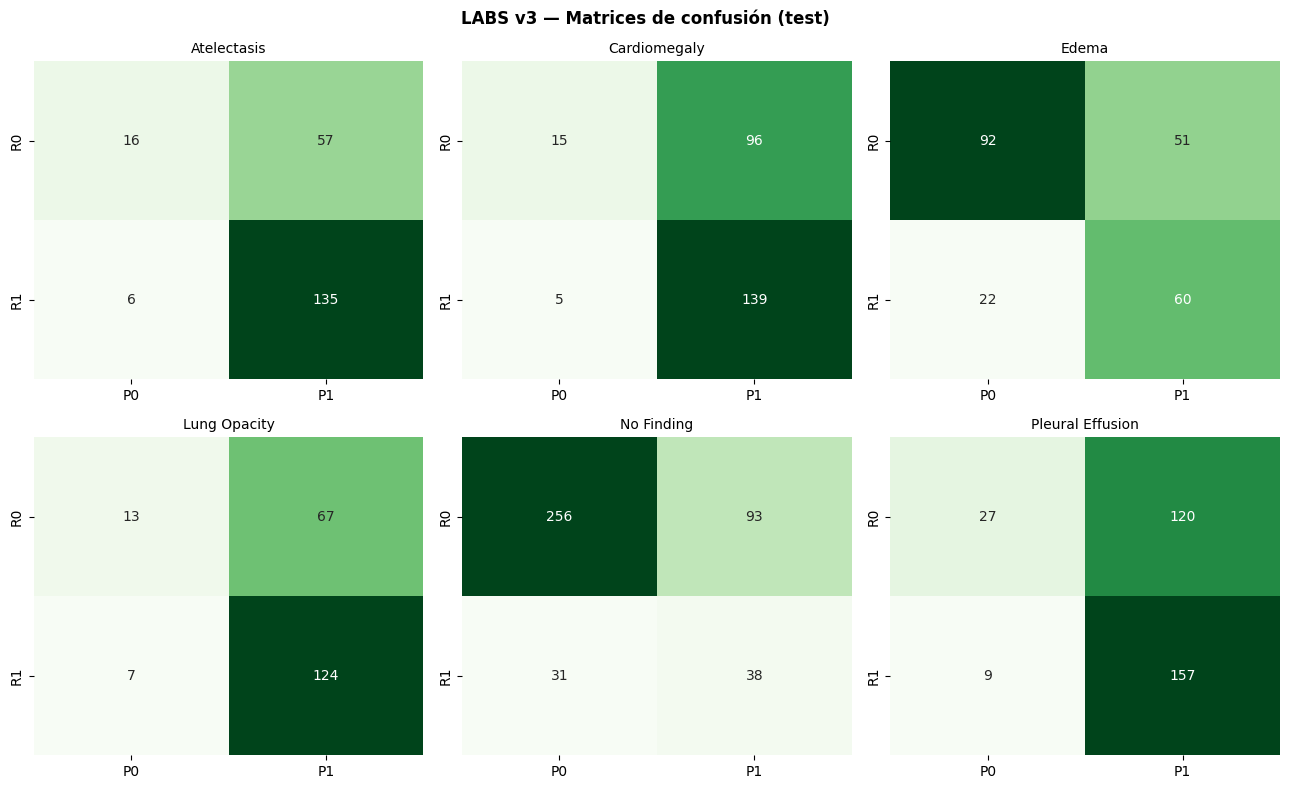

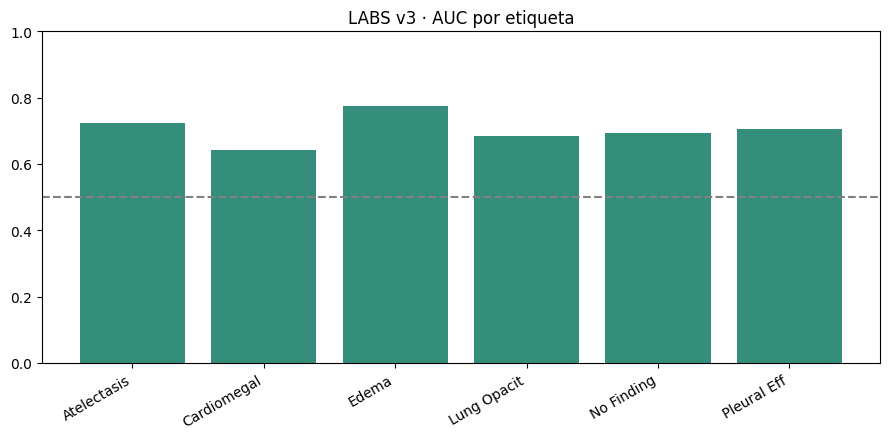

In [28]:
# CELDA 10 · MATRICES DE CONFUSIÓN + AUC por etiqueta
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("LABS v3 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    sns.heatmap(confusion_matrix(yt,yp,labels=[0,1]),annot=True,fmt="d",cmap="Greens",cbar=False,ax=ax,xticklabels=["P0","P1"],yticklabels=["R0","R1"]); ax.set_title(l,fontsize=10)
plt.tight_layout(); plt.savefig(FIG/"confusion_v3.png",dpi=150,bbox_inches="tight"); plt.show()
fig2,ax=plt.subplots(figsize=(9,4.5)); aucs=[M[l]["AUC"] for l in LABELS]
ax.bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],color=["#c0392b" if (np.isnan(a) or a<0.6) else "#117a65" for a in aucs],alpha=0.85)
ax.axhline(0.5,color="gray",ls="--"); ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right")
ax.set_ylim(0,1); ax.set_title("LABS v3 · AUC por etiqueta"); plt.tight_layout(); plt.savefig(FIG/"auc_v3.png",dpi=150,bbox_inches="tight"); plt.show()

In [29]:
# CELDA 11 · EXPORTAR OOF/val/test PARA EL STACKING (hadm_id, labs_<label>, labs_<label>_cal)
def save_predictions(df, raw, cal, name):
    cols={"hadm_id":df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_"); cols[f"labs_{key}"]=raw[:,j]; cols[f"labs_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); p=OUTPUT_DIR/f"labs_pred_{name}.csv"; out.to_csv(p,index=False); print("   guardado",p.name)
save_predictions(df_train, oof_train, oof_cal, "oof_train")
save_predictions(df_val, val_pred_raw, val_pred, "val")
save_predictions(df_test, test_pred_raw, test_pred, "test")
print("OOF/val/test del LABS v3 exportados.")

   guardado labs_pred_oof_train.csv
   guardado labs_pred_val.csv
   guardado labs_pred_test.csv
OOF/val/test del LABS v3 exportados.


In [ ]:
# CELDA 11b · IMPORTANCIA Gini vs MI/ANOVA (B5) + dependencia de los flags MNAR (B7)
#             + consistencia (B6) + estratificacion por subgrupos (B8)
# ORIGEN EDA · §10 "en Opacidad, fiarse mas de MI/ANOVA que de RF-Gini por el desbalanceo"
#              §6  "vigilar que el modelo no dependa en exceso del patron de ausencia (flags)"
#              §3  "P(normal) util como chequeo de consistencia"
#              §2/§9 "evaluar equidad por sexo y etnia" · ANEXO CXR "monitorizar cxr_view"

# ── B5 · Importancia por Gini (XGBoost sobre la matriz de arboles) ────────────────────────────
imp=np.zeros(TREE_tr.shape[1])
for j in range(N_LABELS):
    sel=m_train[:,j]==1; yj=y_train[sel,j]
    if len(np.unique(yj))<2: continue
    w=(yj==0).sum()/max((yj==1).sum(),1); clf=mk_xgb(w); clf.fit(TREE_tr[sel],yj)
    fi=clf.feature_importances_; imp+=fi/(fi.sum()+1e-9)
imp/=N_LABELS

# Nombres legibles de las columnas de TREE (mismo orden que build_tree)
TREE_NAMES=([c.rsplit("_",1)[0].replace("_"," ").title() for c in RAW_LABS]
            +(CLUSTER_NAMES if USE_CLUSTER_REPR else [])
            +["BUN/Creatinina","Neutrofilos/Linfocitos","RDW x Edad"]
            +[f"falta:{c.rsplit('_',1)[0]}" for c in FLAG_LABS]
            +[f"demo_{k}" for k in range(TREE_tr.shape[1]
               -len(RAW_LABS)-(len(CLUSTER_NAMES) if USE_CLUSTER_REPR else 0)-3-len(FLAG_LABS))])

imp_alt=importancia_mi_anova(TREE_tr,y_train,m_train,TREE_NAMES)
imp_alt.to_csv(OUTPUT_DIR/"importancia_mi_anova.csv",index=False)
print("== B5 · Top-10 por Informacion Mutua + ANOVA ==")
print(imp_alt.head(10).to_string(index=False))

# ── B7 · dependencia de los flags de missingness ──────────────────────────────────────────────
dep=flag_importance_share(imp,TREE_NAMES)
print(f"\n== B7 · Importancia acumulada en flags MNAR (Gini): {dep['pct_importancia_flags']:.1f} % "
      f"(flag mas influyente: {dep['flag_top']})")
if dep["pct_importancia_flags"]>25:
    print("   [AVISO] >25 %: parte del rendimiento puede ser ARTEFACTO del proceso asistencial")
    print("           ('le pidieron analitica => esta grave') y no generalizaria a otro hospital.")
json.dump(dep,open(OUTPUT_DIR/"dependencia_flags_mnar.json","w",encoding="utf-8"),indent=2,ensure_ascii=False)

# ── B6 · consistencia de "Sin hallazgo" ───────────────────────────────────────────────────────
cons=consistency_no_finding(test_pred)
print(f"\n== B6 · corr(P(Sin hallazgo), max P(patologia))={cons['corr_NoFinding_vs_maxPatologia']:.3f} "
      f"(debe ser NEGATIVA) · incoherentes={cons['pct_incoherentes']:.1f} %")
json.dump(cons,open(OUTPUT_DIR/"consistencia_no_finding.json","w",encoding="utf-8"),indent=2,ensure_ascii=False)

# ── B8 · equidad y robustez por subgrupo (incluye la proyeccion radiografica) ─────────────────
strat=stratified_report(df_test,test_pred,y_test,m_test)
print("\n== B8 · Rendimiento por subgrupo (n<60 => posible ruido, no inequidad) ==")
print(strat.to_string(index=False,float_format=lambda v:f"{v:.4f}"))
strat.to_csv(OUTPUT_DIR/"estratificacion_subgrupos.csv",index=False)

# ── Figuras: Gini (flags en rojo) vs MI+ANOVA, y AP frente a su linea base ────────────────────
order=np.argsort(imp)[::-1][:20]
fig,axes=plt.subplots(1,2,figsize=(16,6.5))
cols=["#c0392b" if str(TREE_NAMES[i]).startswith("falta:") else "#5b8db8" for i in order][::-1]
axes[0].barh([TREE_NAMES[i] for i in order][::-1],[imp[i] for i in order][::-1],color=cols)
axes[0].set_title("Importancia Gini (top 20)\nrojo = flag de missingness"); axes[0].tick_params(labelsize=8)
ta=imp_alt.head(20).iloc[::-1]
axes[1].barh(ta["variable"],ta["media"],color="#117a65"); axes[1].tick_params(labelsize=8)
axes[1].set_title("Importancia media MI + ANOVA (top 20)")
plt.tight_layout(); plt.savefig(FIG/"importancia_v3.png",dpi=150,bbox_inches="tight"); plt.show()

fig2,ax=plt.subplots(figsize=(9,4.5))
aps=[M[l]["AP"] for l in LABELS]; prevs=[M[l]["prevalencia"] for l in LABELS]; x=np.arange(N_LABELS)
ax.bar(x-0.2,aps,0.4,label="AUC-PR obtenida",color="#117a65")
ax.bar(x+0.2,prevs,0.4,label="prevalencia (linea base)",color="#bdc3c7")
ax.set_xticks(x); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right"); ax.set_ylim(0,1)
ax.set_title("LABS v3 · AUC-PR vs linea base (verde por encima de gris = senal real)"); ax.legend()
plt.tight_layout(); plt.savefig(FIG/"ap_vs_prevalencia_v3.png",dpi=150,bbox_inches="tight"); plt.show()
print("\nGuardados: importancia_mi_anova.csv · dependencia_flags_mnar.json · consistencia_no_finding.json · estratificacion_subgrupos.csv")



---
## ✅ Resumen — LABS v3 (pesado)
**Stacking de 2º nivel**: modelos base diversos (XGB, LGB, LogReg, MLP + TabPFN nube) generan OOF, y un **meta-LogReg por
etiqueta** los combina; se compara con el promedio simple y se elige **por AUC-PR OOF**. Adopta el **etiquetado FINAL**
(negativo = 0 + NaN→0; −1 enmascarado; **sin** derivar de *No Finding*), **AUC-PR con IC bootstrap**, **RobustScaler**,
scores de **clusters fisiológicos** y la regla de **NaN amplio** en la rama densa.

### 📌 Para la documentación posterior (recuadros naranjas a redactar con los resultados)
- **Stacking vs promedio**: si difieren en milésimas y sus **IC se solapan**, no afirmar superioridad → es la
  evidencia del **techo de la señal tabular** que anticipaba el EDA (§5/§8).
- **AP vs prevalencia**: comprobar que cada AP supera su prevalencia (línea base). Si no la supera, la etiqueta
  no es aprendible desde analíticas (esperable en **Atelectasia y Opacidad**, §5).
- Comparar v1 / v2 / v3 **con la misma métrica y el mismo etiquetado**; las cifras antiguas **no valen**.
- ¿Aportan algo los **scores de cluster**? Si sí, es argumento para la reducción por representante (`USE_CLUSTER_REPR`).